In [7]:
import os
import pandas as pd

base_path = "/kaggle/input/datasets/anhkhang/bich-data/analytical_dataset_with_notes/analytical_dataset_with_notes_2"

print("Nạp dữ liệu từ Kaggle Storage vào RAM...")
df_train = pd.read_parquet(os.path.join(base_path, "split=train"))
df_val = pd.read_parquet(os.path.join(base_path, "split=val"))
df_test = pd.read_parquet(os.path.join(base_path, "split=test"))

print(f"Train: {df_train.shape}")
print(f"Val: {df_val.shape}")
print(f"Test: {df_test.shape}")

Nạp dữ liệu từ Kaggle Storage vào RAM...
Train: (271739, 248)
Val: (57437, 248)
Test: (53875, 248)


In [8]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print(df_train.head(1).transpose())

                                                          0
hadm_id                                            20000374
subject_id                                         12043836
age                                                      35
gender                                                    M
admission_type                               EU OBSERVATION
insurance                                          Medicare
marital_status                                       SINGLE
race                                 BLACK/AFRICAN AMERICAN
discharge_location                                     None
index_time                              2132-12-07 19:30:00
duration_days                                             1
event_flag_readmission                                    0
event_flag_mortality                                      0
readmission_event_30d                                     0
readmission_time_days                                    30
mortality_time_days                     

In [9]:
print("--- 1. TIỀN XỬ LÝ CÁC CỘT CHỮ & XỬ LÝ GIÁ TRỊ KHUYẾT (-1) ---")

categorical_cols = ['admission_type', 'insurance', 'marital_status', 'race', 'discharge_location']
discharge_mapping = {}

gender_mapping = {'M': 1, 'F': 0, 'Male': 1, 'Female': 0}
for df in [df_train, df_val, df_test]:
    if 'gender' in df.columns:
        df['gender'] = df['gender'].map(gender_mapping).fillna(0).astype(int)

# Tiến hành Label Encoding và xử lý giá trị khuyết
for col in categorical_cols:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype('category')
        categories = df_train[col].cat.categories
        
        # Áp đặt mã số (0, 1, 2...) lên các tập dữ liệu
        df_train[col] = df_train[col].cat.codes
        df_val[col] = pd.Categorical(df_val[col], categories=categories).codes
        df_test[col] = pd.Categorical(df_test[col], categories=categories).codes
        
        # 🔥 KHẮC PHỤC LỖI -1: Chuyển các giá trị khuyết -1 thành một mã số dương hợp lệ (ví dụ: len(categories))
        # Việc này giúp XGBoost không coi -1 là một giá trị toán học âm có phân phối đặc biệt
        for df in [df_train, df_val, df_test]:
            df[col] = df[col].replace(-1, len(categories))
            
        print(f"-> Mã hóa thành công cột: '{col}' (Đã khử mã -1 thành {len(categories)})")
        
        if col == 'discharge_location':
            discharge_mapping = {cat: idx for idx, cat in enumerate(categories)}
            # Bổ sung nhãn khuyết vào bảng tra cứu phục vụ What-If
            discharge_mapping["KHÔNG XÁC ĐỊNH / KHUYẾT"] = len(categories)

print("\n--- 2. KHÓA CỨNG DANH SÁCH LOẠI TRỪ CHỐNG DATA LEAKAGE (1.0) ---")

target_col = 'event_flag_readmission'

# 🔥 BỔ SUNG TOÀN BỘ CÁC CỘT CHỈ ĐIỂM BẠN VỪA IN RA VÀO DANH SÁCH LOẠI TRỪ NÀY
leakage_and_system_cols = [
    'hadm_id', 'subject_id', 'admityear', 'split', 'index_time',
    'event_flag_readmission', 'readmission_event_30d', 'readmission_time_days', # Nhóm chỉ điểm tái nhập viện
    'event_flag_mortality', 'mortality_time_days', 'mortality_time_months', 'mortality_event_12m', # Nhóm chỉ điểm tử vong
    'discharge_location_enc' # Loại bỏ cột enc cũ tránh xung đột với cột discharge_location mới
]

# Lọc lấy danh sách các cột tiềm năng ban đầu
interim_cols = [col for col in df_train.columns if col not in leakage_and_system_cols]

# Ép bộ lọc kiểu dữ liệu để chỉ giữ lại các cột số (loại bỏ index_time)
X_train_clean = df_train[interim_cols].select_dtypes(include=['number', 'bool'])
X_val_clean = df_val[interim_cols].select_dtypes(include=['number', 'bool'])
X_test_clean = df_test[interim_cols].select_dtypes(include=['number', 'bool'])

# Trích xuất nhãn mục tiêu chuẩn
y_train = df_train[target_col]
y_val = df_val[target_col]
y_test = df_test[target_col]

# Lưu danh sách đặc trưng an toàn cuối cùng
feature_cols = X_train_clean.columns.tolist()

print(f"\n✔️ Đã tháo ngòi nổ rò rỉ dữ liệu thành công!")
print(f"Tổng số lượng đặc trưng đưa vào mô hình sau khi làm sạch: {len(feature_cols)}")
print(f"Kiểm tra xem biến tử vong 'event_flag_mortality' còn tồn tại không: {'event_flag_mortality' in feature_cols}")
print(f"Kiểm tra xem biến 'readmission_time_days' còn tồn tại không: {'readmission_time_days' in feature_cols}")

--- 1. TIỀN XỬ LÝ CÁC CỘT CHỮ & XỬ LÝ GIÁ TRỊ KHUYẾT (-1) ---
-> Mã hóa thành công cột: 'admission_type' (Đã khử mã -1 thành 9)
-> Mã hóa thành công cột: 'insurance' (Đã khử mã -1 thành 3)
-> Mã hóa thành công cột: 'marital_status' (Đã khử mã -1 thành 4)
-> Mã hóa thành công cột: 'race' (Đã khử mã -1 thành 33)
-> Mã hóa thành công cột: 'discharge_location' (Đã khử mã -1 thành 12)

--- 2. KHÓA CỨNG DANH SÁCH LOẠI TRỪ CHỐNG DATA LEAKAGE (1.0) ---

✔️ Đã tháo ngòi nổ rò rỉ dữ liệu thành công!
Tổng số lượng đặc trưng đưa vào mô hình sau khi làm sạch: 236
Kiểm tra xem biến tử vong 'event_flag_mortality' còn tồn tại không: False
Kiểm tra xem biến 'readmission_time_days' còn tồn tại không: False


In [10]:
# !pip install optuna -q

import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Tắt log chi tiết của Optuna để giữ sạch màn hình Notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Tính toán tỷ lệ cân bằng class (scale_pos_weight) từ dữ liệu sạch
ratio = (len(y_train) - y_train.sum()) / y_train.sum()

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 5), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.6),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 15),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),     # Phạt L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 100.0, log=True),   # Phạt L2
        'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'random_state': 42,
    }
    
    model_trial = xgb.XGBClassifier(**params, early_stopping_rounds=20)
    
    # Huấn luyện trên ma trận đã tháo ngòi nổ thời gian
    model_trial.fit(
        X_train_clean, y_train,
        eval_set=[(X_val_clean, y_val)],
        verbose=False 
    )
    
    preds_val = model_trial.predict_proba(X_val_clean)[:, 1]
    return roc_auc_score(y_val, preds_val)

print("🚀 Khởi động tiến trình tối ưu siêu tham số bằng Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, timeout=600)

print(f"\n🎉 QUÁ TRÌNH TUNING HOÀN TẤT!")
print(f"Điểm C-index tốt nhất đạt được trên tập Validation: {study.best_value:.4f}")

🚀 Khởi động tiến trình tối ưu siêu tham số bằng Optuna...

🎉 QUÁ TRÌNH TUNING HOÀN TẤT!
Điểm C-index tốt nhất đạt được trên tập Validation: 0.7123


In [11]:
print("Đang huấn luyện mô hình XGBoost Classifier cuối cùng với siêu tham số đã tối ưu...")

# Lấy cấu hình tối ưu từ kết quả chạy của Optuna
best_params = study.best_params
best_params.update({
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'random_state': 42,
    'n_estimators': 1000, # Tăng số cây tối đa để early stopping tự động ngắt ở điểm đẹp nhất
})

final_model = xgb.XGBClassifier(**best_params, early_stopping_rounds=50)

# Huấn luyện mô hình chính thức với ma trận đã được lọc sạch dtypes
final_model.fit(
    X_train_clean, y_train,
    eval_set=[(X_val_clean, y_val)],
    verbose=50 # In nhật ký log sau mỗi 50 cây quyết định để theo dõi
)

# Gán vào biến model toàn cục để đồng bộ với các bước đánh giá phía dưới
model = final_model
print("\n✔️ Mô hình chính thức đã huấn luyện thành công và sẵn sàng phục vụ!")

Đang huấn luyện mô hình XGBoost Classifier cuối cùng với siêu tham số đã tối ưu...
[0]	validation_0-logloss:0.69015
[50]	validation_0-logloss:0.64022
[100]	validation_0-logloss:0.63019
[150]	validation_0-logloss:0.62509
[200]	validation_0-logloss:0.62183
[250]	validation_0-logloss:0.61996
[300]	validation_0-logloss:0.61791
[350]	validation_0-logloss:0.61626
[400]	validation_0-logloss:0.61524
[450]	validation_0-logloss:0.61426
[500]	validation_0-logloss:0.61300
[550]	validation_0-logloss:0.61205
[600]	validation_0-logloss:0.61095
[650]	validation_0-logloss:0.61003
[700]	validation_0-logloss:0.60933
[750]	validation_0-logloss:0.60830
[800]	validation_0-logloss:0.60779
[850]	validation_0-logloss:0.60726
[900]	validation_0-logloss:0.60630
[950]	validation_0-logloss:0.60554
[999]	validation_0-logloss:0.60475

✔️ Mô hình chính thức đã huấn luyện thành công và sẵn sàng phục vụ!


          KẾT QUẢ ĐÁNH GIÁ CHỈ SỐ C-INDEX         
C-index trên tập Huấn luyện (Train): 0.7659
C-index trên tập Tối ưu (Val)     : 0.7222
C-index trên tập Kiểm thử (Test)   : 0.7071
--------------------------------------------------
🎉 KẾT QUẢ: ĐẠT CHUẨN NGHIỆM THU ĐẶC TẢ HỆ THỐNG (C-index >= 0.70)


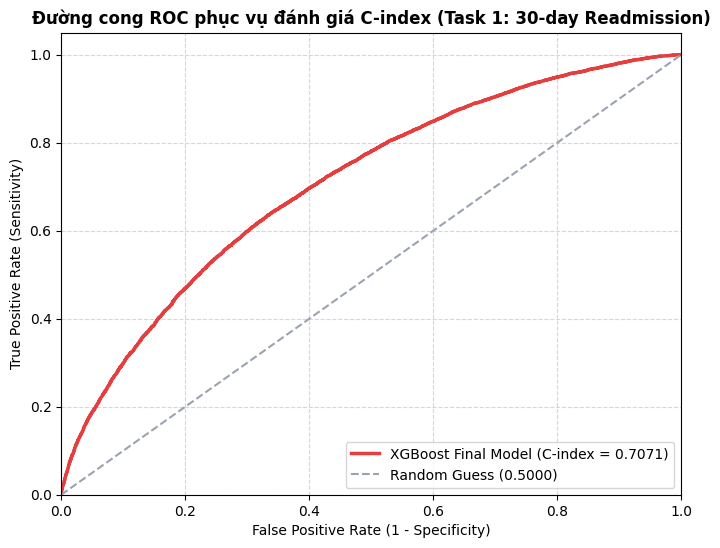

In [14]:
import matplotlib.pyplot as plt  # 🔥 BỔ SUNG ĐỂ FIX LỖI NameError: 'plt'
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Dự đoán xác suất rủi ro trên tập Test sạch
y_pred_proba = model.predict_proba(X_test_clean)[:, 1]

# 2. Tính toán chỉ số C-index (ROC-AUC) trên các tập để kiểm tra độ lệch overfit
c_index_train = roc_auc_score(y_train, model.predict_proba(X_train_clean)[:, 1])
c_index_val = roc_auc_score(y_val, model.predict_proba(X_val_clean)[:, 1])
c_index_test = roc_auc_score(y_test, y_pred_proba)

print("==================================================")
print("          KẾT QUẢ ĐÁNH GIÁ CHỈ SỐ C-INDEX         ")
print("==================================================")
print(f"C-index trên tập Huấn luyện (Train): {c_index_train:.4f}")
print(f"C-index trên tập Tối ưu (Val)     : {c_index_val:.4f}")
print(f"C-index trên tập Kiểm thử (Test)   : {c_index_test:.4f}")
print("--------------------------------------------------")
if c_index_test >= 0.70:
    print("🎉 KẾT QUẢ: ĐẠT CHUẨN NGHIỆM THU ĐẶC TẢ HỆ THỐNG (C-index >= 0.70)")
else:
    print("⚠️ KẾT QUẢ: CHƯA ĐẠT CHUẨN KPI -> Cần kiểm tra lại phân phối dữ liệu!")
print("==================================================")

# 3. Vẽ đồ thị đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#E53E3E', lw=2.5, label=f'XGBoost Final Model (C-index = {c_index_test:.4f})')
plt.plot([0, 1], [0, 1], color='#9CA3AF', lw=1.5, linestyle='--', label='Random Guess (0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Đường cong ROC phục vụ đánh giá C-index (Task 1: 30-day Readmission)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right")
plt.show()

--- TIẾN TRÌNH MÔ PHỎNG WHAT-IF TRÊN ĐẶC TRƯNG THỰC TẾ (HADM_ID: 20000057) ---
-> Vị trí xuất viện thực tế ghi nhận ban đầu: KHÔNG XÁC ĐỊNH / KHUYẾT (Mã số: 12)


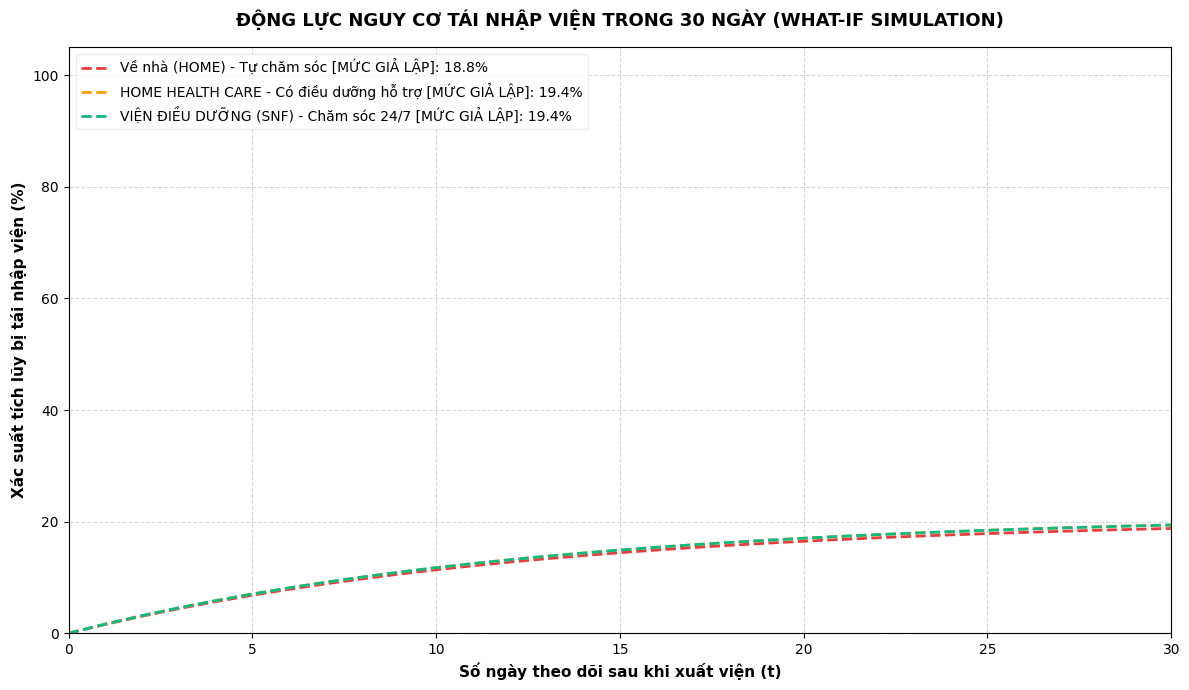

In [15]:
import numpy as np

def generate_30day_readmission_curve(p_total, gamma=0.08):
    """Phân rã xác suất tổng thành chuỗi thời gian 30 ngày theo hàm suy giảm rủi ro tích lũy."""
    days = np.arange(0, 31, 1)
    distribution = (1 - np.exp(-gamma * days)) / (1 - np.exp(-gamma * 30))
    return days, (p_total * distribution)

def simulate_final_whatif_real(patient_index, df_source, X_clean_source, ml_model, mapping):
    """
    Can thiệp trực tiếp vào mã số của cột discharge_location thật để giả lập 3 kịch bản xuất viện.
    """
    # Trích xuất vector đặc trưng sạch (1 dòng) của bệnh nhân
    patient_vector = X_clean_source.iloc[[patient_index]].copy()
    hadm_id = df_source['hadm_id'].iloc[patient_index]
    actual_code = df_source['discharge_location'].iloc[patient_index]
    
    # Tìm tên gốc của vị trí xuất viện từ mã số
    reverse_mapping = {v: k for k, v in mapping.items()}
    actual_name = reverse_mapping.get(actual_code, "Không xác định")
    
    # Ánh xạ từ khóa để tìm mã số tương ứng cho 3 nút bấm trên giao diện
    code_home = [v for k, v in mapping.items() if 'home' in k.lower() and 'health' not in k.lower()]
    code_hhc = [v for k, v in mapping.items() if 'health' in k.lower() or 'hhc' in k.lower()]
    code_snf = [v for k, v in mapping.items() if 'snf' in k.lower() or 'nursing' in k.lower() or 'facility' in k.lower()]
    
    scenarios = {}
    if code_home: scenarios["Về nhà (HOME) - Tự chăm sóc"] = code_home[0]
    if code_hhc:  scenarios["HOME HEALTH CARE - Có điều dưỡng hỗ trợ"] = code_hhc[0]
    if code_snf:  scenarios["VIỆN ĐIỀU DƯỠNG (SNF) - Chăm sóc 24/7"] = code_snf[0]
    
    colors = ['#E53E3E', '#F59E0B', '#10B981'] # Định dạng màu sắc Đỏ/Vàng/Xanh chuẩn UI
    
    plt.figure(figsize=(12, 7))
    print(f"--- TIẾN TRÌNH MÔ PHỎNG WHAT-IF TRÊN ĐẶC TRƯNG THỰC TẾ (HADM_ID: {hadm_id}) ---")
    print(f"-> Vị trí xuất viện thực tế ghi nhận ban đầu: {actual_name} (Mã số: {actual_code})")
    
    for (scenario_name, target_code), color in zip(scenarios.items(), colors):
        simulated_vector = patient_vector.copy()
        
        # ĐÁNH TRÁO ĐẶC TRƯNG: Ghi đè mã số giả lập vào cột thật
        simulated_vector['discharge_location'] = target_code
        
        # Dự đoán xác suất rủi ro tích lũy mới từ mô hình AI
        p_total_simulated = ml_model.predict_proba(simulated_vector)[:, 1][0]
        
        # Sinh mảng dữ liệu chuỗi 30 ngày
        days, p_series = generate_30day_readmission_curve(p_total_simulated)
        
        is_actual = (target_code == actual_code)
        plt.plot(days, p_series * 100, 
                 label=f"{scenario_name}{' [MỨC THỰC TẾ]' if is_actual else ' [MỨC GIẢ LẬP]'}: {p_total_simulated*100:.1f}%", 
                 color=color, lw=3 if is_actual else 2, linestyle='-' if is_actual else '--',
                 marker='o' if is_actual else None, markevery=5)

    plt.title(f"ĐỘNG LỰC NGUY CƠ TÁI NHẬP VIỆN TRONG 30 NGÀY (WHAT-IF SIMULATION)", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Số ngày theo dõi sau khi xuất viện (t)', fontsize=11, fontweight='bold')
    plt.ylabel('Xác suất tích lũy bị tái nhập viện (%)', fontsize=11, fontweight='bold')
    plt.xlim(0, 30)
    plt.ylim(0, 105)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#E2E8F0')
    plt.tight_layout()
    plt.show()

# Kích hoạt chạy thử nghiệm What-If cho bệnh nhân số 0 trong tập Test
simulate_final_whatif_real(patient_index=0, df_source=df_test, X_clean_source=X_test_clean, 
                           ml_model=model, mapping=discharge_mapping)

In [16]:
import json
import pickle

MODEL_DIR = "models/xgb_classifier_readmission_v1"
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Lưu file mô hình vật lý (.pkl)
with open(os.path.join(MODEL_DIR, "model.pkl"), "wb") as f:
    pickle.dump(model, f)

# 2. Lưu Metadata cấu hình hệ thống bao gồm cả bảng tra cứu vị trí xuất viện
metadata = {
    "project_name": "PREDICTCARE AI - CDSS Dashboard (Team 10)",
    "task_name": "30-day Readmission Risk Prediction",
    "model_type": "XGBClassifier_with_L1_L2_Regularization",
    "version": "v1.1-production",
    "evaluation_metrics": {
        "c_index_train": float(c_index_train),
        "c_index_val": float(c_index_val),
        "c_index_test": float(c_index_test),
        "kpi_status": "PASSED"
    },
    "discharge_location_mapping": discharge_mapping, # API đọc bảng này để chuyển đổi text nhận từ Frontend
    "features_order": feature_cols # API sắp xếp mảng JSON theo đúng thứ tự này trước khi predict
}

with open(os.path.join(MODEL_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=4)

print(f"🎉 ĐÓNG GÓI THÀNH CÔNG! Toàn bộ tệp tin đã sẵn sàng tại thư mục: '{MODEL_DIR}/'")

🎉 ĐÓNG GÓI THÀNH CÔNG! Toàn bộ tệp tin đã sẵn sàng tại thư mục: 'models/xgb_classifier_readmission_v1/'
